# 06 — O4 : couverture, routes et auto-écoles (préfecture)

Ce notebook **montre** les données de O4. Il ne produit aucun chiffre du 06 : ces chiffres viennent des CSV écrits par `scripts/exploration_06.py` (`data/analysis/06_exploration/`) et des tables du 05 (R-19). Il n'applique aucun seuil du 02, ne classe pas et ne calcule aucun score. Un écart est décrit, pas expliqué ; une date de la chronologie est une coïncidence, pas une cause (H1).

**Ce qu'on regarde** : les km de routes classées par type, les auto-écoles comptées (R-12) rapportées à la population, leur concentration par zone, la desserte et la densité routières, la distance des points de départ à l'auto-école comptée la plus proche, et le croisement routes × auto-écoles. L'offre de formation est en C : activité non vérifiée (R-12).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
from IPython.display import display
from style_06 import *
appliquer_style()
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 200)

In [2]:
p = prefectures_geo()
ae = gpd.read_file(TRAITE / "geo" / "auto_ecoles.geojson").to_crs(UTM31N)

## Km de routes classées, par type (O4-01)

Préfectures groupées par zone, dans l'ordre alphabétique : aucun classement.

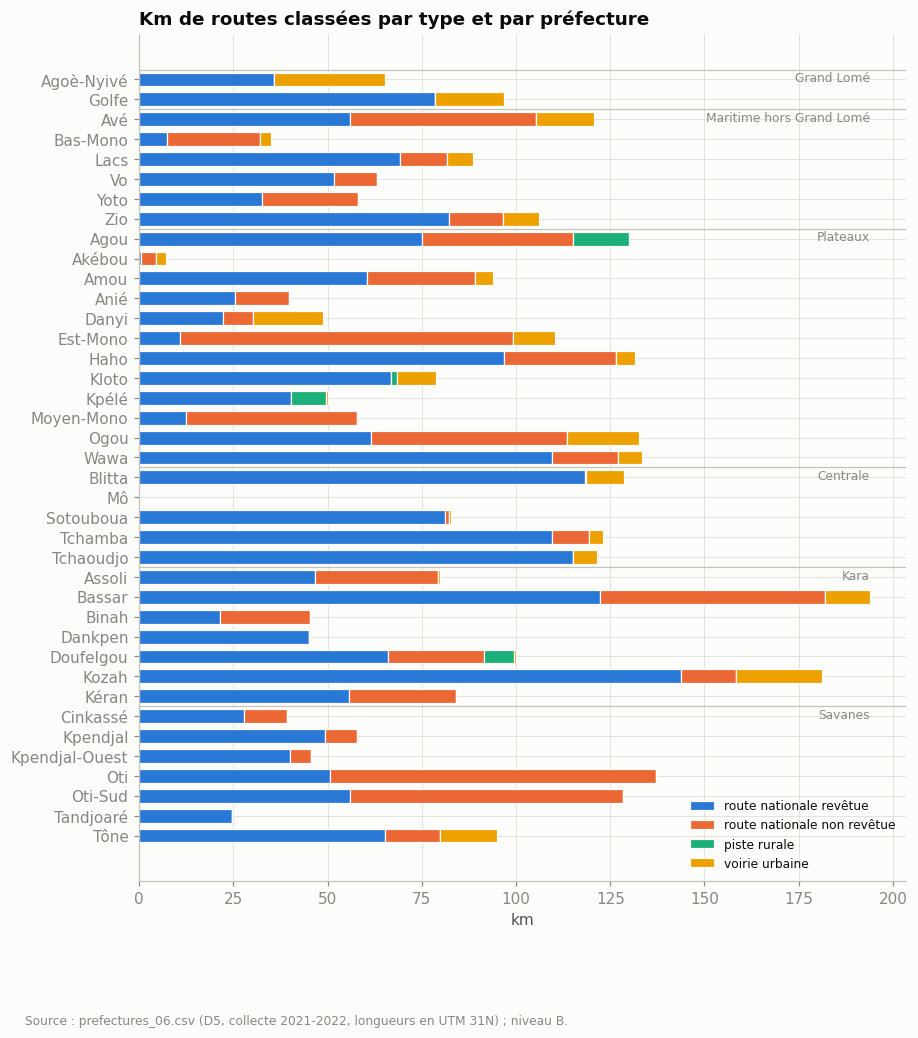

,Effectif,Minimum,Q1,Médiane,Q3,Maximum,Valeurs atypiques
Variable,,,,,,,
Km de routes classées,39,0.0,49.45,84.0,122.25,193.9,NaN
Km de route nationale revêtue,39,0.0,30.15,55.6,76.85,143.7,NaN
Km de route nationale non revêtue,39,0.0,2.50,14.4,29.00,88.4,"Est-Mono (88,4) ; Oti (86,6) ; Oti-Sud (72,6)"
Km de piste rurale,39,0.0,0.00,0.0,0.00,14.9,"Agou (14,9) ; Kpélé (9,2) ; Doufelgou (8,0) ; Kloto (1,7)"
Km de voirie urbaine,39,0.0,0.00,2.5,10.25,29.6,"Agoè-Nyivé (29,6)"


In [3]:
types = ["Km de route nationale revêtue", "Km de route nationale non revêtue", "Km de piste rurale", "Km de voirie urbaine"]
d = p.assign(_z=p["Zone"].map({z: i for i, z in enumerate(ZONES)})).sort_values(["_z", "Préfecture"]).set_index("Préfecture")
fig, ax = plt.subplots(figsize=(9, 10))
gauche = np.zeros(len(d))
for couleur, t in zip(SERIES, types):
    ax.barh(d.index, d[t], left=gauche, color=couleur, edgecolor=SURFACE, linewidth=0.8, label=t.replace("Km de ", ""), height=0.7)
    gauche += d[t].to_numpy()
for i, z in enumerate(d["Zone"]):
    if i == 0 or d["Zone"].iloc[i - 1] != z:
        ax.axhline(i - 0.5, color=AXE, linewidth=0.8)
        ax.annotate(z, (gauche.max(), i - 0.4), ha="right", va="top", fontsize=8, color=MUET)
ax.invert_yaxis(); ax.set_xlabel("km"); ax.legend(fontsize=8, loc="lower right")
ax.set_title("Km de routes classées par type et par préfecture")
pied(fig, "Source : prefectures_06.csv (D5, collecte 2021-2022, longueurs en UTM 31N) ; niveau B.")
plt.show()
display(exploration("distributions").set_index("Variable").loc[["Km de routes classées"] + types,
        ["Effectif", "Minimum", "Q1", "Médiane", "Q3", "Maximum", "Valeurs atypiques"]])

## Auto-écoles comptées pour 100 000 habitants (O4-04 à O4-07)

Hachures : préfectures sans auto-école comptée (zéro mesuré). Points : auto-écoles comptées (orange) et non comptées (gris). Le tableau donne aussi les habitants par auto-école comptée, lecture inverse, non définie sans auto-école.

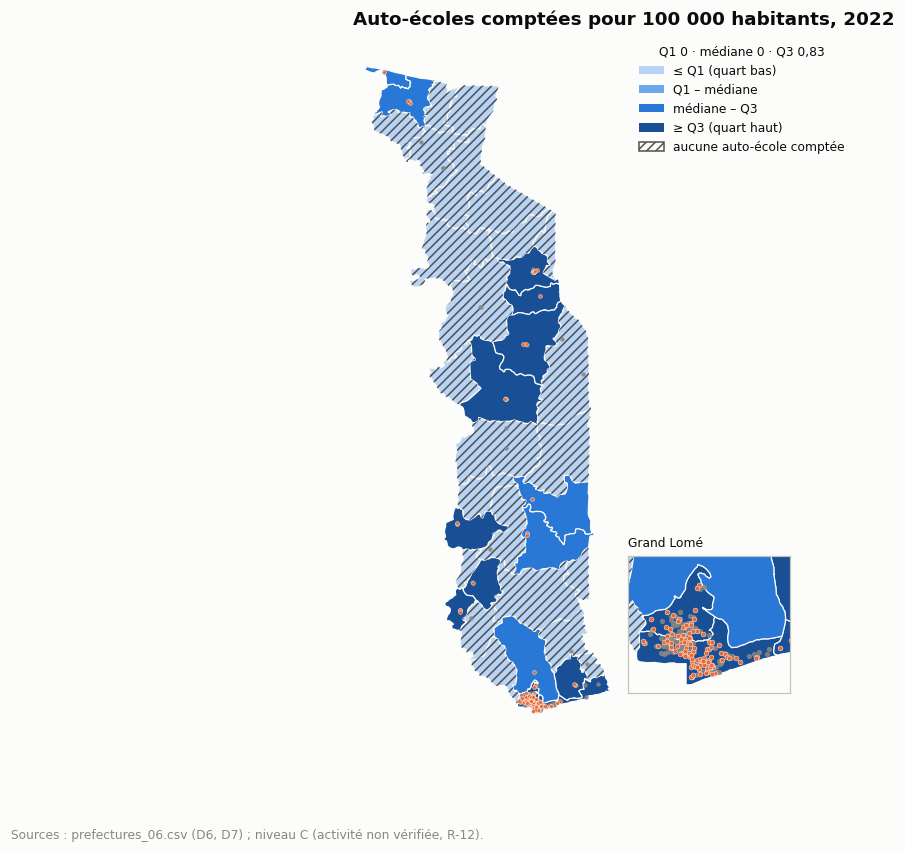

,Zone,Population 2022,Auto-écoles recensées,Auto-écoles comptées,Auto-écoles comptées pour 100 000 habitants,Habitants par auto-école comptée
Préfecture,,,,,,
Agou,Plateaux,85793,1,0,0.00,NaN
Agoè-Nyivé,Grand Lomé,882695,69,29,3.29,30438.0
Akébou,Plateaux,73830,0,0,0.00,NaN
Amou,Plateaux,114172,1,0,0.00,NaN
Anié,Plateaux,180158,1,1,0.56,180158.0
Assoli,Kara,66394,1,1,1.51,66394.0
Avé,Maritime hors Grand Lomé,111214,0,0,0.00,NaN
Bas-Mono,Maritime hors Grand Lomé,94860,1,0,0.00,NaN
Bassar,Kara,152065,2,0,0.00,NaN


In [4]:
fig, ax, g = choroplethe(p, "Auto-écoles comptées pour 100 000 habitants", "Auto-écoles comptées pour 100 000 habitants, 2022",
                        "Sources : prefectures_06.csv (D6, D7) ; niveau C (activité non vérifiée, R-12).", zero="aucune auto-école comptée")
ins = ax.child_axes[0]
for a, taille in ((ax, 6), (ins, 10)):
    ae[~ae["Comptée (R-12)"]].plot(ax=a, color=MUET, markersize=taille * 0.6, alpha=0.8)
    ae[ae["Comptée (R-12)"]].plot(ax=a, color=SERIES[1], markersize=taille, edgecolor=SURFACE, linewidth=0.3)
    a.set_xlabel(""); a.set_ylabel("")
plt.show()
display(p[["Préfecture", "Zone", "Population 2022", "Auto-écoles recensées", "Auto-écoles comptées",
           "Auto-écoles comptées pour 100 000 habitants", "Habitants par auto-école comptée"]].set_index("Préfecture"))

## Concentration : part des auto-écoles comptées et part de la population, 6 zones (H8)

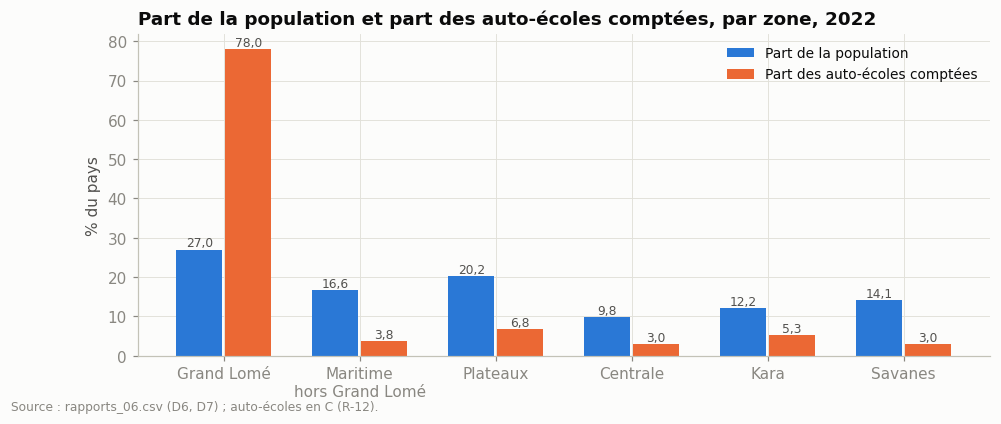

Rapport,Part de la population,Part des auto-écoles comptées
Territoire,,
Grand Lomé,27.0,78.0
Maritime hors Grand Lomé,16.6,3.8
Plateaux,20.2,6.8
Centrale,9.8,3.0
Kara,12.2,5.3
Savanes,14.1,3.0


In [5]:
z = exploration("rapports")
z = z[(z["Maille"] == "Zone") & z["Rapport"].isin(["Part de la population", "Part des auto-écoles comptées"])]
z = z.pivot(index="Territoire", columns="Rapport", values="Valeur").reindex(ZONES)
fig, ax = plt.subplots(figsize=(10, 3.8))
x = np.arange(len(z))
for i, (couleur, col) in enumerate(zip(SERIES, z.columns)):
    ax.bar(x + (i - 0.5) * 0.36, z[col], width=0.34, color=couleur, label=col)
    for xi, v in zip(x, z[col]):
        ax.annotate(f"{v:.1f}".replace(".", ","), (xi + (i - 0.5) * 0.36, v), xytext=(0, 2), textcoords="offset points", ha="center", fontsize=8, color=ENCRE_2)
ax.set_xticks(x, [e.replace(" hors", "\nhors") for e in z.index]); ax.set_ylabel("% du pays"); ax.legend(fontsize=9)
ax.set_title("Part de la population et part des auto-écoles comptées, par zone, 2022")
pied(fig, "Source : rapports_06.csv (D6, D7) ; auto-écoles en C (R-12).")
plt.show()
display(z)

## Desserte : km de routes pour 10 000 habitants (O4-03)

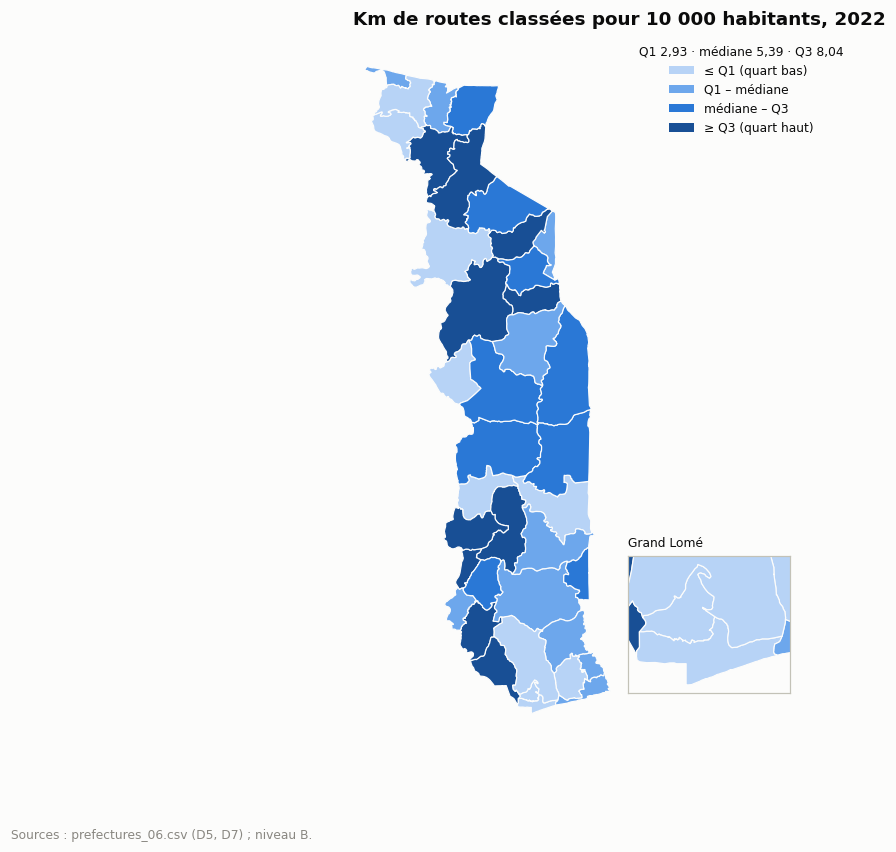

,Zone,Km de routes classées,Population 2022,Km pour 10 000 habitants
Préfecture,,,,
Agou,Plateaux,130.2,85793,15.17
Agoè-Nyivé,Grand Lomé,65.3,882695,0.74
Akébou,Plateaux,7.0,73830,0.94
Amou,Plateaux,93.8,114172,8.21
Anié,Plateaux,39.8,180158,2.21
Assoli,Kara,79.8,66394,12.01
Avé,Maritime hors Grand Lomé,120.8,111214,10.86
Bas-Mono,Maritime hors Grand Lomé,34.9,94860,3.68
Bassar,Kara,193.9,152065,12.75


In [6]:
fig, ax, g = choroplethe(p, "Km pour 10 000 habitants", "Km de routes classées pour 10 000 habitants, 2022",
                        "Sources : prefectures_06.csv (D5, D7) ; niveau B.")
plt.show()
display(p[["Préfecture", "Zone", "Km de routes classées", "Population 2022", "Km pour 10 000 habitants"]].set_index("Préfecture"))

## Densité routière : km pour 1 000 km² (O4-02)

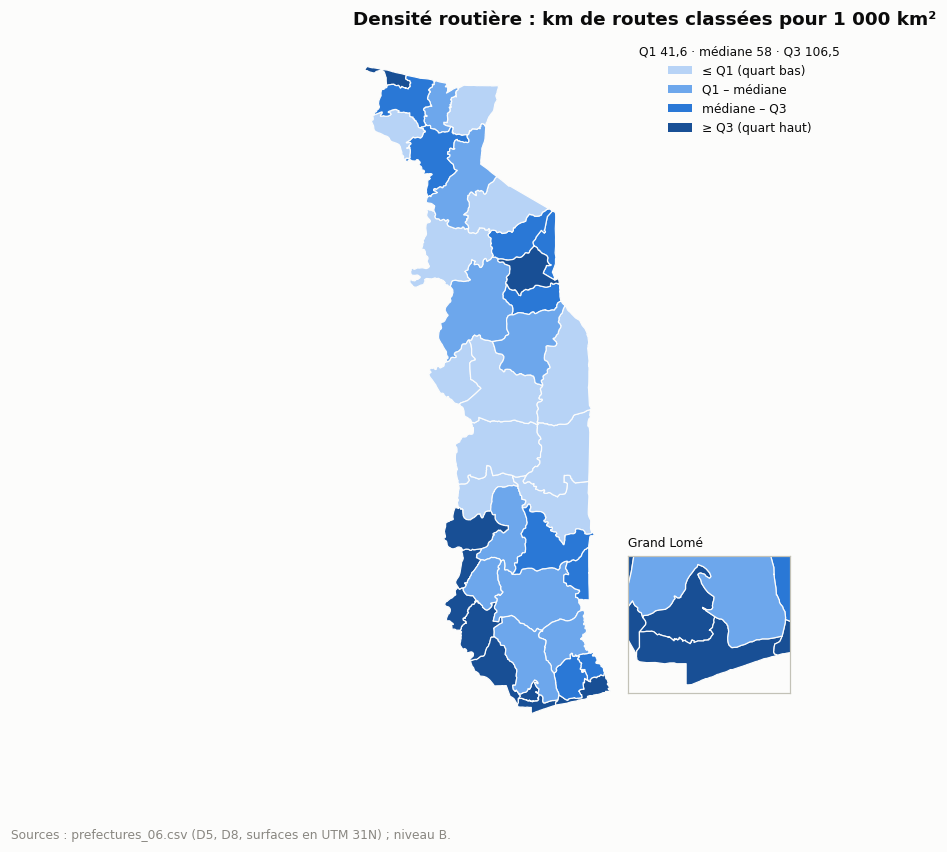

,Zone,Km de routes classées,Surface (km²),Km pour 1 000 km²
Préfecture,,,,
Agou,Plateaux,130.2,1095.98,118.8
Agoè-Nyivé,Grand Lomé,65.3,167.10,390.5
Akébou,Plateaux,7.0,1146.67,6.1
Amou,Plateaux,93.8,1808.50,51.8
Anié,Plateaux,39.8,1985.91,20.0
Assoli,Kara,79.8,933.27,85.5
Avé,Maritime hors Grand Lomé,120.8,1049.85,115.1
Bas-Mono,Maritime hors Grand Lomé,34.9,329.40,105.8
Bassar,Kara,193.9,3456.90,56.1


In [7]:
fig, ax, g = choroplethe(p, "Km pour 1 000 km²", "Densité routière : km de routes classées pour 1 000 km²",
                        "Sources : prefectures_06.csv (D5, D8, surfaces en UTM 31N) ; niveau B.")
plt.show()
display(p[["Préfecture", "Zone", "Km de routes classées", "Surface (km²)", "Km pour 1 000 km²"]].set_index("Préfecture"))

## Distance à l'auto-école comptée la plus proche (repli de O4-08)

Depuis le point de départ de chaque préfecture (chef-lieu, ou point d'étiquette : losange), à vol d'oiseau, en UTM 31N. En C.

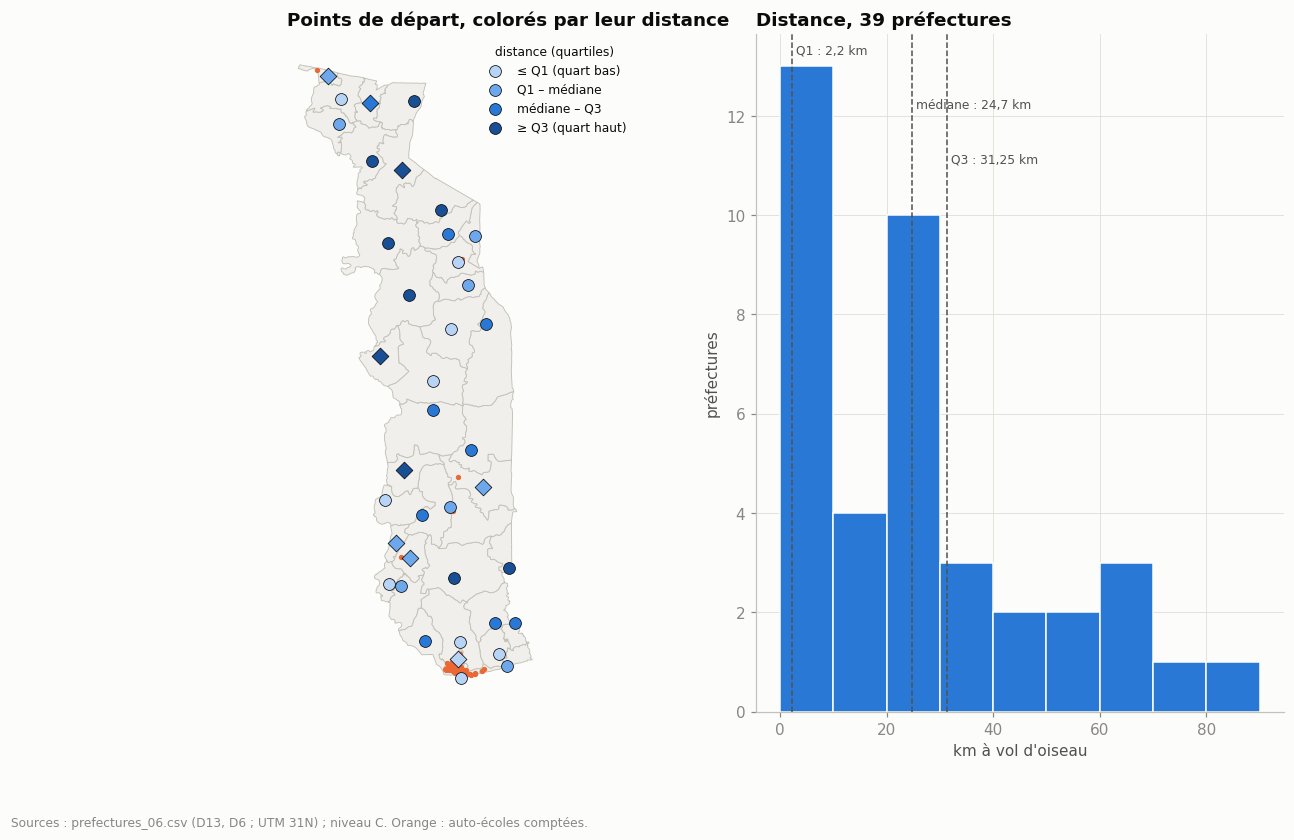

,Origine,Distance à l’auto-école comptée la plus proche (km),Préfecture de l’auto-école la plus proche
Préfecture,,,
Agou,chef-lieu HDX,11.0,Kloto
Agoè-Nyivé,point d'étiquette HDX,1.8,Agoè-Nyivé
Akébou,point d'étiquette HDX,31.3,Wawa
Amou,chef-lieu HDX,28.4,Ogou
Anié,point d'étiquette HDX,24.7,Anié
Assoli,chef-lieu HDX,2.6,Assoli
Avé,chef-lieu HDX,28.5,Agoè-Nyivé
Bas-Mono,chef-lieu HDX,31.2,Vo
Bassar,chef-lieu HDX,47.5,Tchaoudjo


In [8]:
var = "Distance à l’auto-école comptée la plus proche (km)"
d = distribution(var)
pts = lire("D13_points_depart_o4_08").merge(exploration("prefectures")[["Préfecture", var, "Préfecture de l’auto-école la plus proche"]], on="Préfecture")
pts = gpd.GeoDataFrame(pts, geometry=gpd.points_from_xy(pts["x_utm"], pts["y_utm"]), crs=UTM31N)
pts["_classe"] = [classe(v, d) for v in pts[var]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 8), gridspec_kw={"width_ratios": [1, 1.1]})
p.plot(ax=a1, color="#f0efec", edgecolor=AXE, linewidth=0.6)
ae[ae["Comptée (R-12)"]].plot(ax=a1, color=SERIES[1], markersize=6)
for c, couleur in zip(CLASSES, SEQUENTIEL):
    s = pts[pts["_classe"] == c]
    for origine, marque in (("chef-lieu HDX", "o"), ("point d'étiquette HDX", "D")):
        s[s["Origine"] == origine].plot(ax=a1, color=couleur, markersize=60, marker=marque, edgecolor=ENCRE, linewidth=0.5, label=c if origine == "chef-lieu HDX" else None)
nettoyer(a1); a1.legend(fontsize=8, loc="upper left", bbox_to_anchor=(0.72, 1), title="distance (quartiles)", title_fontsize=8)
a1.set_title("Points de départ, colorés par leur distance")
a2.hist(pts[var], bins=np.arange(0, pts[var].max() + 10, 10), color=SERIES[0], edgecolor=SURFACE)
for q, nom, h in ((d["Q1"], "Q1", 0.97), (d["Médiane"], "médiane", 0.89), (d["Q3"], "Q3", 0.81)):
    a2.axvline(q, color=ENCRE_2, linestyle="--", linewidth=1)
    a2.annotate(f"{nom} : {q:g} km".replace(".", ","), (q, a2.get_ylim()[1] * h), xytext=(3, 0), textcoords="offset points", fontsize=8, color=ENCRE_2)
a2.set_xlabel("km à vol d'oiseau"); a2.set_ylabel("préfectures"); a2.set_title("Distance, 39 préfectures")
pied(fig, "Sources : prefectures_06.csv (D13, D6 ; UTM 31N) ; niveau C. Orange : auto-écoles comptées.")
plt.show()
display(pts[["Préfecture", "Origine", var, "Préfecture de l’auto-école la plus proche"]].set_index("Préfecture"))

## Routes et auto-écoles (O4-03 × O4-05)

Taille : population. Deux couleurs : classe de PA-03. Traits : Q1 et Q3 de chaque axe (06 §4). Noms : valeurs atypiques (06 §4).

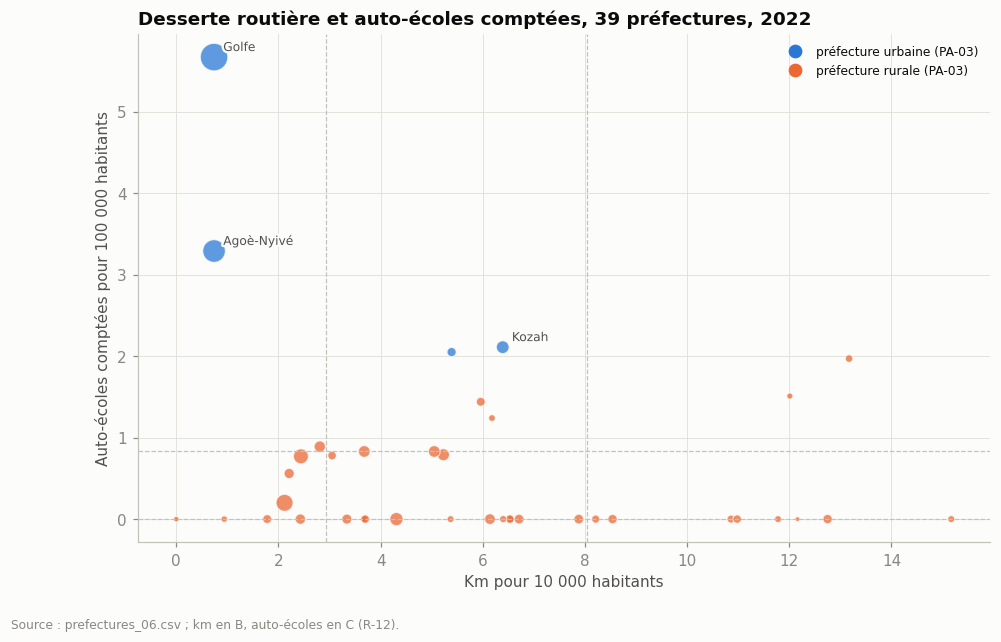

In [9]:
x, y = "Km pour 10 000 habitants", "Auto-écoles comptées pour 100 000 habitants"
fig, ax = plt.subplots(figsize=(10, 6))
for couleur, cl in zip(SERIES, ["urbaine", "rurale"]):
    s = p[p["Classe PA-03"] == cl]
    ax.scatter(s[x], s[y], s=s["Population 2022"] / 4000, color=couleur, alpha=0.75, edgecolor=SURFACE, linewidth=0.8, label=f"préfecture {cl} (PA-03)")
for var, ligne in ((x, ax.axvline), (y, ax.axhline)):
    dd = distribution(var)
    for q in (dd["Q1"], dd["Q3"]):
        ligne(q, color=AXE, linestyle="--", linewidth=0.8)
atyp = set()
for var in (x, y):
    v = distribution(var)["Valeurs atypiques"]
    atyp |= set() if pd.isna(v) else {e.split(" (")[0] for e in v.split(" ; ")}
for _, r in p[p["Préfecture"].isin(atyp)].iterrows():
    ax.annotate(r["Préfecture"], (r[x], r[y]), xytext=(6, 4), textcoords="offset points", fontsize=8, color=ENCRE_2, path_effects=HALO)
from matplotlib.lines import Line2D
ax.set_xlabel(x); ax.set_ylabel(y)
ax.legend(handles=[Line2D([], [], marker="o", linestyle="none", color=c, markersize=8, label=f"préfecture {cl} (PA-03)") for c, cl in zip(SERIES, ["urbaine", "rurale"])], fontsize=8)
ax.set_title("Desserte routière et auto-écoles comptées, 39 préfectures, 2022")
pied(fig, "Source : prefectures_06.csv ; km en B, auto-écoles en C (R-12).")
plt.show()

## Signaux de O4 (`signaux_06.csv`)

In [10]:
display(signaux(objectif="O4"))

,Résumé,Niveau,Question transmise
ID,,,
SIG-16,"Km de route nationale non revêtue : 3 préfecture(s) hors des bornes de Tukey (-37,25 ; 68,75) : Est-Mono (88,4) ; Oti (86,6) ; Oti-Sud (...",B,"Le classement tient-il sans ces valeurs ? Le 08 le vérifie (sensibilité au point extrême, 05_Priorisation)."
SIG-17,"Km de piste rurale : 4 préfecture(s) hors des bornes de Tukey (0,00 ; 0,00) : Agou (14,9) ; Kpélé (9,2) ; Doufelgou (8,0) ; Kloto (1,7)",B,"Le classement tient-il sans ces valeurs ? Le 08 le vérifie (sensibilité au point extrême, 05_Priorisation)."
SIG-18,"Km de voirie urbaine : 1 préfecture(s) hors des bornes de Tukey (-15,38 ; 25,62) : Agoè-Nyivé (29,6)",B,"Le classement tient-il sans ces valeurs ? Le 08 le vérifie (sensibilité au point extrême, 05_Priorisation)."
SIG-19,"Km pour 1 000 km² : 3 préfecture(s) hors des bornes de Tukey (-55,75 ; 203,85) : Golfe (401,9) ; Agoè-Nyivé (390,5) ; Lacs (213,3)",B,"Le classement tient-il sans ces valeurs ? Le 08 le vérifie (sensibilité au point extrême, 05_Priorisation)."
SIG-22,"Auto-écoles recensées : 3 préfecture(s) hors des bornes de Tukey (-3,8 ; 6,2) : Golfe (143) ; Agoè-Nyivé (69) ; Kozah (11)",A,"Le classement tient-il sans ces valeurs ? Le 08 le vérifie (sensibilité au point extrême, 05_Priorisation)."
SIG-23,"Auto-écoles comptées : 3 préfecture(s) hors des bornes de Tukey (-3,0 ; 5,0) : Golfe (74) ; Agoè-Nyivé (29) ; Kozah (6)",A,"Le classement tient-il sans ces valeurs ? Le 08 le vérifie (sensibilité au point extrême, 05_Priorisation)."
SIG-24,"Auto-écoles comptées pour 100 000 habitants : 3 préfecture(s) hors des bornes de Tukey (-1,245 ; 2,075) : Golfe (5,67) ; Agoè-Nyivé (3,2...",C,"Le classement tient-il sans ces valeurs ? Le 08 le vérifie (sensibilité au point extrême, 05_Priorisation)."
SIG-25,"Distance à l’auto-école comptée la plus proche (km) : 1 préfecture(s) hors des bornes de Tukey (-41,38 ; 74,83) : Oti-Sud (84,0)",C,"Le classement tient-il sans ces valeurs ? Le 08 le vérifie (sensibilité au point extrême, 05_Priorisation)."
SIG-26,"Auto-écoles comptées pour 100 000 habitants : 23 préfectures sur 39 sont ex aequo au minimum (0,00), plus d’un tiers",C,Le tercile inférieur de SE-07 ne peut pas séparer ces ex aequo : comment le 08 coupe-t-il ? À trancher avant de voir le classement (R-20).
